In [3]:
# import libraries

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# import data as csv
df = pd.read_csv("Dataset/clean_dataset.csv")

df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


### Data Overview

In [5]:
overview_data = {
        "Metric": ["Total Rows", "Total Columns", "Duplicate Rows", "Total Missing Cells", "Memory Usage"],
        "Value": [
            f"{df.shape[0]:,}", 
            f"{df.shape[1]:,}", 
            f"{df.duplicated().sum():,}", 
            f"{df.isnull().sum().sum():,}",
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
        ]
    }
pd.DataFrame(overview_data)

,Metric,Value
0,Total Rows,"12,575"
1,Total Columns,11
2,Duplicate Rows,0
3,Total Missing Cells,"7,229"
4,Memory Usage,5.62 MB


### Initial Inspection 

In [6]:
inspection_df = pd.DataFrame({
    "dtype": df.dtypes,
    "Missing Value": df.isnull().sum().values,
    "Non-missing value": df.notnull().sum().values,
    "Percentage of Missing(%)": (df.isnull().sum().values/len(df)*100).round(2),
    "Unqiue Values": df.nunique().values
})


inspection_df

,dtype,Missing Value,Non-missing value,Percentage of Missing(%),Unqiue Values
Transaction ID,object,0,12575,0.00,12575
Customer ID,object,0,12575,0.00,25
Category,object,0,12575,0.00,8
Item,object,1213,11362,9.65,200
Price Per Unit,float64,609,11966,4.84,25
Quantity,float64,604,11971,4.80,10
Total Spent,float64,604,11971,4.80,227
Payment Method,object,0,12575,0.00,3
Location,object,0,12575,0.00,2
Transaction Date,object,0,12575,0.00,1114


### Cleaning

In [7]:
# Checking for incorrect Datatype and converting if found
print(df.dtypes)

# Transaction Date has datatype of object that is incorrect, converting to Datetime 
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object


Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied            object
dtype: object

In [8]:
# Percentage of Missing values
print((df.isnull().sum()/len(df)*100).round(2))

Transaction ID       0.00
Customer ID          0.00
Category             0.00
Item                 9.65
Price Per Unit       4.84
Quantity             4.80
Total Spent          4.80
Payment Method       0.00
Location             0.00
Transaction Date     0.00
Discount Applied    33.39
dtype: float64


In [9]:
# Handling Missing value by imputing mean for numerical col and mode for categorical col

df['Item']= df['Item'].fillna(df['Item'].mode()[0]) # Item(Categorial)
df['Discount Applied'] = df['Discount Applied'].fillna(df['Transaction Date'].mode()[0]) # Discount Applied


df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].mean()) # Price Per Unit(Numerical)
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean()) # Quantity
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].mean()) # Total Spent


# After
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Index(['Price Per Unit', 'Quantity', 'Total Spent'], dtype='object')


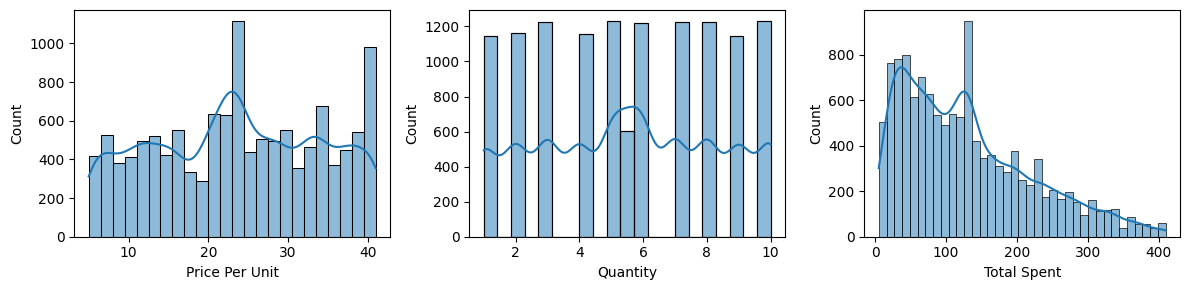

In [17]:
#Checking for any outlier and handle them efficiently
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)

# Normal Distribution

plt.figure(figsize=(12,3))

plt.subplot(1,3,1)
sns.histplot(df['Price Per Unit'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Quantity'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Total Spent'], kde=True)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Total Spent')

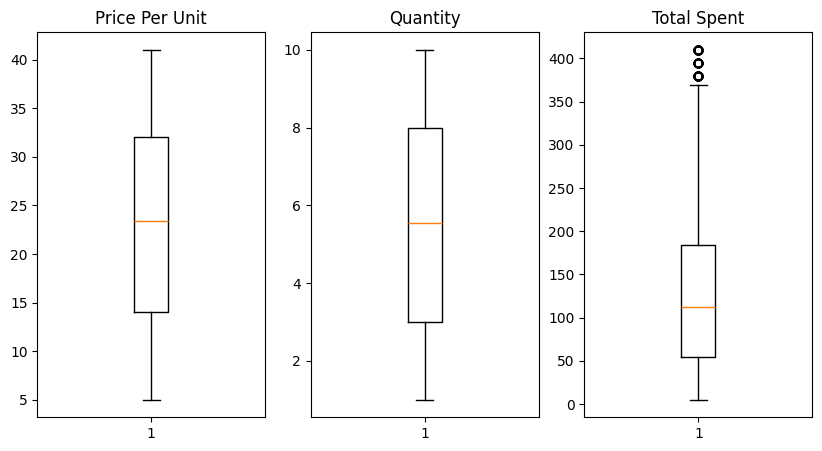

In [ ]:
# Detecting Outlier using Boxplot

fig, axes = plt.subplots(1,3,figsize=(10,5))

# ploting boxplot for Price Per Unit in first subplot
axes[0].boxplot(df['Price Per Unit'])
axes[0].set_title('Price Per Unit')

# ploting boxplot for Quantity in first subplot
axes[1].boxplot(df['Quantity'])
axes[1].set_title('Quantity')

# ploting boxplot for Total Spent in first subplot
axes[2].boxplot(df['Total Spent'])
axes[2].set_title('Total Spent')

#### Conclusion

* Missing values were handled by imputing the mode for categorical columns and the mean for numerical columns

* No duplicate records were found in the dataset

* No outliers were detected in the numerical columns based on the IQR method

In [ ]:
# cleaned data sorted in csv file

df.to_csv("cleaned_data.csv", index=False)